# Combined Clonal Assignment: HDBI58

In [3]:
import pandas as pd
import numpy as np
import pickle
import sklearn
import platform
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
color_map = LinearSegmentedColormap.from_list('ss2_to_10x', ['lightgrey', 'red', 'darkred'])
import gzip


# Merge fq.gz files from Timepoint 1 and Timepoint 2

In [1]:
cat ./LARRY_sorted_and_filtered_barcodes_D3.fastq.gz ./LARRY_sorted_and_filtered_barcodes_D10.fastq.gz ./LARRY_sorted_and_filtered_barcodes_D17High.fastq.gz ./LARRY_sorted_and_filtered_barcodes_D17Mid.fastq.gz > ./combined_D3D10D17.fastq.gz

# Merge valid_cbc and library files

In [4]:
T1_valid_cbc = np.loadtxt('./cell_bcs_flat_D3.txt', dtype='str')

In [5]:
T2_valid_cbc = np.loadtxt('./cell_bcs_flat_D10.txt', dtype='str')

In [6]:
T3a_valid_cbc = np.loadtxt('./cell_bcs_flat_D17High.txt', dtype='str')

In [7]:
T3b_valid_cbc = np.loadtxt('./cell_bcs_flat_D17Mid.txt', dtype='str')

In [8]:
valid_cbc_combined = np.concatenate([T1_valid_cbc, T2_valid_cbc, T3a_valid_cbc, T3b_valid_cbc])


In [9]:
np.savetxt('cell_bcs_flat_combined_D3D10D17.txt', valid_cbc_combined, fmt='%s')

In [10]:
T1_lib = np.loadtxt('./samp_id_flat_D3.txt', dtype='str')

In [11]:
T2_lib = np.loadtxt('./samp_id_flat_D10.txt', dtype='str')

In [12]:
T3a_lib = np.loadtxt('./samp_id_flat_D17High.txt', dtype='str')

In [13]:
T3b_lib = np.loadtxt('./samp_id_flat_D17Mid.txt', dtype='str')

In [14]:
lib_combined = np.concatenate([T1_lib, T2_lib, T3a_lib, T3b_lib])


In [15]:
np.size(lib_combined)

29528

In [16]:
np.savetxt('samp_id_flat_combined_D3D10D17.txt', lib_combined, fmt='%s')

# New Pipeline

In [124]:
import numpy as np, matplotlib.pyplot as plt, networkx as nx, pickle, json, gzip
%matplotlib inline

# Set Parameters

N_READS: Cutoff for the min number of reads supporting a given UMI/GFP-BC pair in a particular cell

N_UMIS: Cutoff for the min number of UMIs supporting a given cell/GFP-BC pair

N_HAMMING: Cutoff for the max hamming distance to collapse two GFP-BCs

CELL_BCS_PATH: Path to a .txt file with one cell-BC per line, corresponding to rows of the gene expression counts matrix

LIB_NAMES_PATH: Path to a .txt file with one library name per line, corresponding to rows of the gene expression counts matrix

In [22]:
N_READS = 6
N_UMIS = 3
N_HAMMING = 3
CELL_BCS_PATH = 'cell_bcs_flat_combined_D3D10D17.txt'
LIB_NAMES_PATH = 'samp_id_flat_combined_D3D10D17.txt'

# Read input files

In [19]:
cell_bcs = open(CELL_BCS_PATH).read().strip('\n').split('\n')
lib_names = open(LIB_NAMES_PATH).read().strip('\n').split('\n')

# Load data and count reads

Read in the output of step 1 (LARRY_sorting_and_filtering.py) and count the number of reads supporting each (Sample, Cell-BC, UMI, GFP-BC) combination



In [20]:
counts = {}
f = gzip.open('combined_D3D10D17.fastq.gz')
l = f.readline().decode("utf-8").strip('\n')
current_tag = []
i = 0
print('Reading in all barcodes')
while not (l == '' and len(current_tag)==0):
    i += 1
    if i % (3*10**6)==0: print('Processed '+repr(int(i/3))+' reads')
    if l == '':
        current_tag = []
    elif l[0] == '>':
        current_tag = l[1:].split(',')
    elif l != '' and len(current_tag)==3:
        current_tag.append(l)
        current_tag = tuple(current_tag)
        if not current_tag in counts: counts[current_tag] = 0
        counts[current_tag] += 1
        
    l = f.readline().decode("utf-8").strip('\n')

Reading in all barcodes
Processed 1000000 reads
Processed 2000000 reads
Processed 3000000 reads
Processed 4000000 reads
Processed 5000000 reads
Processed 6000000 reads
Processed 7000000 reads
Processed 8000000 reads
Processed 9000000 reads
Processed 10000000 reads
Processed 11000000 reads
Processed 12000000 reads
Processed 13000000 reads
Processed 14000000 reads
Processed 15000000 reads
Processed 16000000 reads
Processed 17000000 reads
Processed 18000000 reads
Processed 19000000 reads
Processed 20000000 reads
Processed 21000000 reads
Processed 22000000 reads
Processed 23000000 reads
Processed 24000000 reads
Processed 25000000 reads
Processed 26000000 reads
Processed 27000000 reads
Processed 28000000 reads
Processed 29000000 reads
Processed 30000000 reads
Processed 31000000 reads
Processed 32000000 reads
Processed 33000000 reads
Processed 34000000 reads
Processed 35000000 reads
Processed 36000000 reads
Processed 37000000 reads
Processed 38000000 reads
Processed 39000000 reads
Processed 

# Filter by number of reads

Continue with analysis with (Sample, Cell-BC, UMI, GFP-BC) combinations supported by at least N_READS reads

Retaining 2900710 out of 8076660 (Sample,Cell-BC,UMI,GFP-BC) combinations


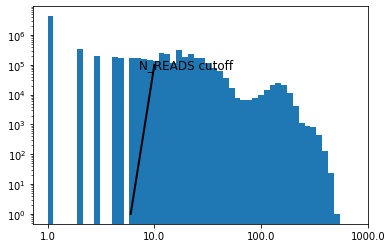

In [23]:
num_reads = [v for k,v in counts.items()]
plt.hist(np.log(num_reads)/np.log(10), bins=50)
plt.plot([np.log(N_READS)/np.log(10),np.log(N_READS)/np.log(N_READS)],[1,10**5],'-k',linewidth=2)
plt.xticks(range(4),np.logspace(0,3,4))
plt.text(np.log(N_READS)/np.log(10)*1.1,10**5*.8,'N_READS cutoff', fontsize=12)
plt.yscale('log')

counts_filtered = {k:v for k,v in counts.items() if v >= N_READS}
print('Retaining '+repr(len(counts_filtered))+ ' out of '+repr(len(counts))+' (Sample,Cell-BC,UMI,GFP-BC) combinations')


# Collapse GFP-BCs by hamming distance

In [24]:
def hamming(bc1,bc2): return np.sum([x1 != x2 for x1,x2 in zip(bc1,bc2)])

all_gfp_bcs = sorted(set([k[3] for k in counts_filtered]))
good_gfp_bcs = []
bc_map = {}
for i,bc1 in enumerate(all_gfp_bcs):
    if i > 0 and i % 500 == 0: print('Mapped '+repr(i)+' out of '+repr(len(all_gfp_bcs))+' barcodes')
    mapped = False
    for bc2 in good_gfp_bcs:
        if hamming(bc1,bc2) <= N_HAMMING:
            mapped = True
            bc_map[bc1] = bc2
            break
    if not mapped:
        good_gfp_bcs.append(bc1)

print('\nCollapsed '+repr(len(bc_map))+' barcodes')
for bc in good_gfp_bcs: bc_map[bc] = bc

Mapped 500 out of 8994 barcodes
Mapped 1000 out of 8994 barcodes
Mapped 1500 out of 8994 barcodes
Mapped 2000 out of 8994 barcodes
Mapped 2500 out of 8994 barcodes
Mapped 3000 out of 8994 barcodes
Mapped 3500 out of 8994 barcodes
Mapped 4000 out of 8994 barcodes
Mapped 4500 out of 8994 barcodes
Mapped 5000 out of 8994 barcodes
Mapped 5500 out of 8994 barcodes
Mapped 6000 out of 8994 barcodes
Mapped 6500 out of 8994 barcodes
Mapped 7000 out of 8994 barcodes
Mapped 7500 out of 8994 barcodes
Mapped 8000 out of 8994 barcodes
Mapped 8500 out of 8994 barcodes

Collapsed 4859 barcodes


# Filter GFP-barcodes by UMI

Index (UMI, GFP-BC) combinations to cells, then filter out BCs supported by fewer than N_UMIS UMIs


Final annotation has 3941 clones in 19597 cells


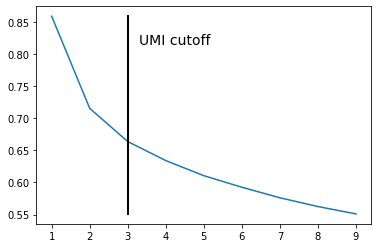

In [25]:
cell_data = {}
for lib,cell in zip(lib_names,cell_bcs):
    cell_data[(lib,cell)] = {}

for lib,cell,umi,BC in counts_filtered.keys():
    if (lib,cell) in cell_data:
        if not BC in cell_data[(lib,cell)]:
            cell_data[(lib,cell)][BC] = 0
        cell_data[(lib,cell)][BC] += 1

BC_lists = []
for i in range(1,10):
    BC_list = []
    for lib,cell in zip(lib_names,cell_bcs):
        bc_counts = cell_data[(lib,cell)]
        valid_bcs = [bc_map[k] for k,v in bc_counts.items() if v >= i]
        BC_list.append(''.join(sorted(valid_bcs)))
    BC_lists.append(BC_list)

efficiency = np.array([len([ll for ll in l if len(ll)>0]) for l in BC_lists]) / len(cell_bcs)
plt.plot(range(1,10),efficiency)
plt.plot([N_UMIS,N_UMIS],[np.min(efficiency),np.max(efficiency)],'-k',linewidth=2)
plt.text(N_UMIS*1.1,np.max(efficiency)*.95,'UMI cutoff',fontsize=14)

final_BCs = BC_lists[N_UMIS-1]
print('\nFinal annotation has '+repr(len(set(final_BCs)))+' clones in '+repr(len([l for l in final_BCs if len(l)>0]))+' cells')

# Output clonal anotations

There are three output files:

clone_mat.csv 

clone_mat.npy

barcode_list.txt

The two clone_mat files store a binary matrix where rows are cells and columns are clones. A "1" at entry (i,j) indicates that cell i belongs to clone j. The barcode_list file stores the barcode for each cell. Two barcode strings separated by an underscore indicates that the cell contains multiple barcodes. An empty line implies no barcode for that cell.

In [26]:
BC_set = sorted(set([bc for bc in final_BCs if bc != '']))
clone_mat = np.zeros((len(final_BCs),len(BC_set)))
for i,bc in enumerate(final_BCs):
    if bc != '':
        j = BC_set.index(bc)
        clone_mat[i,j] = 1
clone_mat = np.array(clone_mat,dtype=int)
np.savetxt('clone_mat_combined_D3D10D17.csv',clone_mat,delimiter=',',fmt='%i');
np.save('clone_mat_combined_D3D10D17.npy',clone_mat);
open('barcode_list_combined_D3D10D17.txt','w').write('\n'.join(final_BCs));

# Pre-QC Summary Statistics

In [27]:
list_clones = []
for i in range(1, np.shape(clone_mat)[1] + 1):
    list_clones.append('Clone_{}'.format(i))

In [28]:
df_clones = pd.DataFrame(clone_mat, columns = list_clones, index = cell_bcs)

In [29]:
df_clones

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3931,Clone_3932,Clone_3933,Clone_3934,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940
SITTG7AAACCCACAAATCAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACCCAGTTGCTCGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAAAGAGGTATT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAACAAGCAGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAATCAGGACGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGTTGTCAAGTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCCACTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCGAGGCAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCTGCATAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df_clones

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3931,Clone_3932,Clone_3933,Clone_3934,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940
SITTG7AAACCCACAAATCAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACCCAGTTGCTCGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAAAGAGGTATT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAACAAGCAGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAATCAGGACGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGTTGTCAAGTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCCACTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCGAGGCAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCTGCATAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
library = [i[:6] for i in df_clones.index]

In [32]:
timepoint = []
for i in library:
    if i == 'SITTG7':
        timepoint.append('Day3')
    elif i == 'SITTB5':
        timepoint.append('Day10')
    elif i == 'SITTC9':
        timepoint.append('Day17')
    elif i == 'SITTB9':
        timepoint.append('Day17')
gfp = []
for i in library:
    if i == 'SITTG7':
        gfp.append('')
    elif i == 'SITTB5':
        gfp.append('')
    elif i == 'SITTC9':
        gfp.append('high')
    elif i == 'SITTB9':
        gfp.append('mid')

In [33]:
df_clones['Timepoint'] = timepoint

In [34]:
df_clones['gfp_late'] = gfp

In [35]:
df_clones

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3933,Clone_3934,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940,Timepoint,gfp_late
SITTG7AAACCCACAAATCAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day3,
SITTG7AAACCCAGTTGCTCGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day3,
SITTG7AAACGAAAGAGGTATT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day3,
SITTG7AAACGAACAAGCAGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day3,
SITTG7AAACGAATCAGGACGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day3,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGTTGTCAAGTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day17,mid
SITTB9TTTGTTGTCCACTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day17,mid
SITTB9TTTGTTGTCGAGGCAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day17,mid
SITTB9TTTGTTGTCTGCATAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Day17,mid


In [36]:
df_clones.to_pickle('./clonal_dataframe_combined_D3D10D17.pkl')

In [37]:
df_clones = pd.read_pickle('./clonal_dataframe_combined_D3D10D17.pkl')

In [38]:
np.where(df_clones['Clone_1'])

(array([ 3767,  4076,  4304,  5133,  5621,  5699,  6567,  7268,  7362,
         7815, 21790]),)

In [39]:
list_Day3 = []
list_Day10 = []
list_Day17 = []
list_Day3Day10 = []
list_Day3Day17 = []
list_Day10Day17 = []
list_Day3Day10Day17 = []
for i in df_clones.columns[:-2]:
    times = df_clones['Timepoint'][np.where(df_clones[i])[0]]
    unique = np.unique(times)
    if np.size(unique)==1:
        if unique[0] == 'Day3':
            list_Day3.append(i)
        elif unique[0] == 'Day10':
            list_Day10.append(i)
        elif unique[0] == 'Day17':
            list_Day17.append(i)
    elif np.size(unique)==2:
        if list(unique) == ['Day10', 'Day3']:
            list_Day3Day10.append(i)
        elif list(unique) == ['Day10', 'Day17']:
            list_Day10Day17.append(i)
        elif list(unique) == ['Day17', 'Day3']:
            list_Day3Day17.append(i)
    elif np.size(unique)==3:
        list_Day3Day10Day17.append(i)
        
        

In [40]:
np.size(list_Day3)

1817

In [41]:
np.size(list_Day10)

443

In [42]:
np.size(list_Day17)

1039

In [43]:
np.size(list_Day3Day10)

133

In [44]:
np.size(list_Day3Day17)

50

In [45]:
np.size(list_Day10Day17)

333

In [46]:
np.size(list_Day3Day10Day17)

125

In [48]:
list_Day3Day10Day17

['Clone_55',
 'Clone_59',
 'Clone_89',
 'Clone_103',
 'Clone_189',
 'Clone_256',
 'Clone_284',
 'Clone_287',
 'Clone_388',
 'Clone_429',
 'Clone_541',
 'Clone_632',
 'Clone_648',
 'Clone_651',
 'Clone_688',
 'Clone_691',
 'Clone_743',
 'Clone_754',
 'Clone_765',
 'Clone_772',
 'Clone_812',
 'Clone_832',
 'Clone_841',
 'Clone_998',
 'Clone_1012',
 'Clone_1155',
 'Clone_1212',
 'Clone_1213',
 'Clone_1214',
 'Clone_1230',
 'Clone_1253',
 'Clone_1299',
 'Clone_1346',
 'Clone_1362',
 'Clone_1466',
 'Clone_1481',
 'Clone_1496',
 'Clone_1540',
 'Clone_1563',
 'Clone_1630',
 'Clone_1717',
 'Clone_1758',
 'Clone_1816',
 'Clone_1867',
 'Clone_1944',
 'Clone_1959',
 'Clone_1964',
 'Clone_1966',
 'Clone_2149',
 'Clone_2209',
 'Clone_2228',
 'Clone_2232',
 'Clone_2291',
 'Clone_2298',
 'Clone_2383',
 'Clone_2387',
 'Clone_2425',
 'Clone_2457',
 'Clone_2463',
 'Clone_2468',
 'Clone_2491',
 'Clone_2499',
 'Clone_2505',
 'Clone_2539',
 'Clone_2550',
 'Clone_2557',
 'Clone_2560',
 'Clone_2561',
 'Clone

# Cells per Clone

In [49]:
np.max(np.array(df_clones.iloc[:,:-2].sum(axis = 0)))

619

In [51]:
np.log10(619)

2.791690649020118

Text(0, 0.5, 'Frequency')

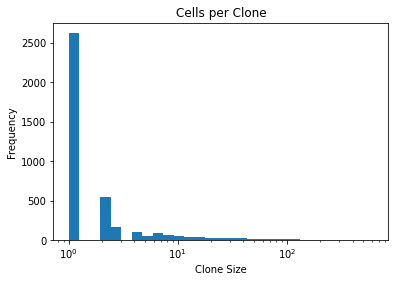

In [52]:
plt.hist(df_clones.iloc[:,:-2].sum(axis = 0), bins=10**np.linspace(0, 2.79, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

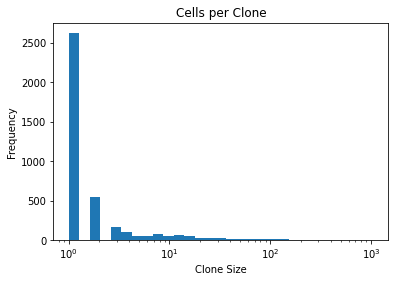

In [133]:
plt.hist(df_clones.iloc[:,:-2].sum(axis = 0), bins=10**np.linspace(0, 3.02, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

# Barcodes per Cell

In [55]:
#final_BCs

In [56]:
length_checker = np.vectorize(len)
number_nucleotides_len = length_checker(final_BCs)

In [57]:
number_barcode = number_nucleotides_len/40

In [58]:
df_clones['Number_Barcodes'] = number_barcode

In [59]:
df_clones['Clonal Barcode'] = final_BCs

Text(0, 0.5, 'Frequency')

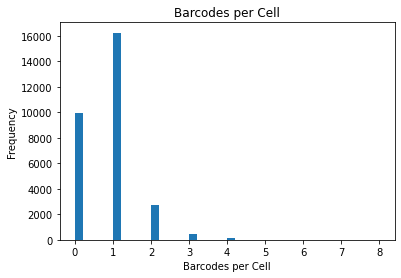

In [60]:
plt.hist(df_clones['Number_Barcodes'], bins =40)
plt.xticks()
plt.title("Barcodes per Cell")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

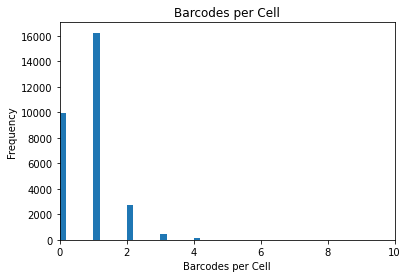

In [134]:
plt.hist(df_clones['Number_Barcodes'], bins =40)
plt.xticks()
plt.xlim([0,10])
plt.title("Barcodes per Cell")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

# Cells per Clone: D3

In [64]:
df_early = df_clones[df_clones['Timepoint']=='Day3']

In [65]:
df_early

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940,Timepoint,gfp_late,Number_Barcodes,Clonal Barcode
SITTG7AAACCCACAAATCAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,AGAGTGCCATCACCCGACGACCGACAACGTACACAGCTCC
SITTG7AAACCCAGTTGCTCGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,ACACTGTAGACACAACACAACCGATAATGTCACGAGAGGG
SITTG7AAACGAAAGAGGTATT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,2.0,ATAATGTGAACAGCGTACCACGGAAATAGTCAAGAGACCGTAACTA...
SITTG7AAACGAACAAGCAGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,GACATGGGATCAAGATACACGGGAAGAAGTAAAGAGGCAA
SITTG7AAACGAATCAGGACGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,AGGCGGGTGTCATATAACAATTGAACGCGTTAAAAGCGAC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTG7TTTGTTGGTCAGCTTA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,AAATTGTATTCAAGTAACCTAGGAACACGTAAACAGATCG
SITTG7TTTGTTGGTTGTATGC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,2.0,CGATTGTATACAAATAACTTGTGATAATGTTACAAGTAAATAGTTG...
SITTG7TTTGTTGTCAACTTTC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,ACCCTGCAGGCAGCGCACCCGAGATAAAGTCTGTAGCTTT
SITTG7TTTGTTGTCTGCCTGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,4.0,ATCCTGATGCCATGCGACCTTTGATGAAGTGCGAAGCATTCGCCTG...


In [66]:
np.max(np.array(df_early.iloc[:,:-4].sum(axis = 0)))

7

In [67]:
np.log10(7)

0.8450980400142568

Text(0, 0.5, 'Frequency')

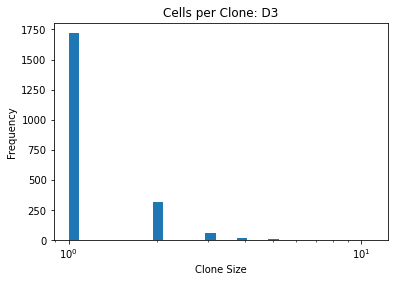

In [136]:
plt.hist(df_early.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 1.041, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D3")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

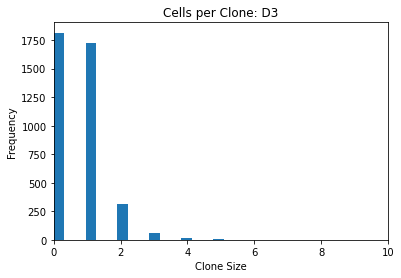

In [135]:
plt.hist(df_early.iloc[:,:-4].sum(axis = 0), bins=22)
plt.xticks()
plt.xlim([0,10])
plt.title("Cells per Clone: D3")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

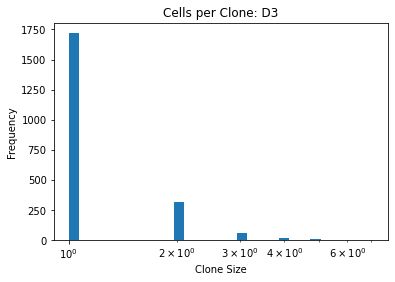

In [70]:
plt.hist(df_early.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 0.85, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D3")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

# Barcodes per Cell: D3

Text(0, 0.5, 'Frequency')

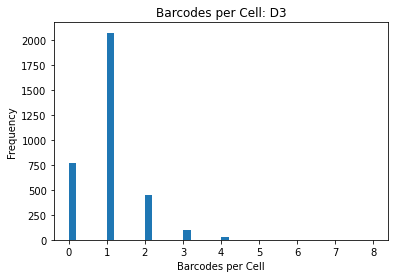

In [71]:
plt.hist(df_early['Number_Barcodes'], bins =40)
plt.xticks()
plt.title("Barcodes per Cell: D3")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

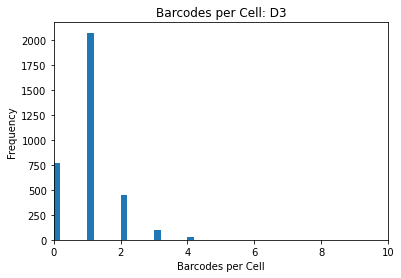

In [72]:
plt.hist(df_early['Number_Barcodes'], bins =40)
plt.xticks()
plt.xlim([0,10])
plt.title("Barcodes per Cell: D3")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

In [73]:
np.mean(df_early['Number_Barcodes'])

0.99620548744892

# Cells per Clone: D10

In [74]:
df_mid = df_clones[df_clones['Timepoint']=='Day10']

In [75]:
df_mid

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940,Timepoint,gfp_late,Number_Barcodes,Clonal Barcode
SITTB5AAACCCAAGTCATGCT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,0.0,
SITTB5AAACCCACACCGTGCA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAGATGATAGCAGTACACAAGAGATTCCGTCTAAAGTTAC
SITTB5AAACCCACAGAGAAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,0.0,
SITTB5AAACCCAGTCTGTCCT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,GAAGTGCAGCCAAAATACAGAGGATCAAGTTGTAAGCGAT
SITTB5AAACCCATCGCCGAGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAATTGCTAACAAGCGACAAGAGAATGGATATAGAGAAAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB5TTTGTTGCAAGAATAC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,0.0,
SITTB5TTTGTTGCATCCGGCA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,0.0,
SITTB5TTTGTTGGTGTCCGTG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,2.0,AACCTGTGCCAAAATGACCCCCGAAGTAGTAAGCAGACTAGATATG...
SITTB5TTTGTTGGTTTGAACC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,TTTCTGCTGACAAAACACCGCAGATCAAGTTATCAGTAGC


In [76]:
np.max(np.array(df_mid.iloc[:,:-4].sum(axis = 0)))

37

In [77]:
np.log10(37)

1.568201724066995

Text(0, 0.5, 'Frequency')

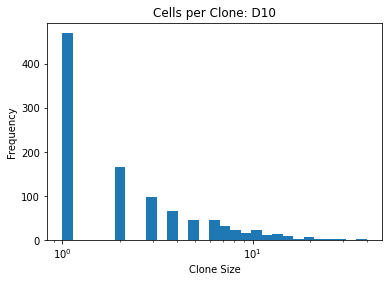

In [78]:
plt.hist(df_mid.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 1.6, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D10")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

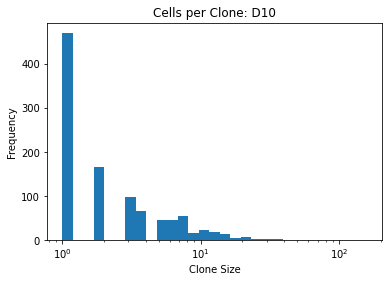

In [137]:
plt.hist(df_mid.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 2.2, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D10")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

# Barcodes per Cell: D10

Text(0, 0.5, 'Frequency')

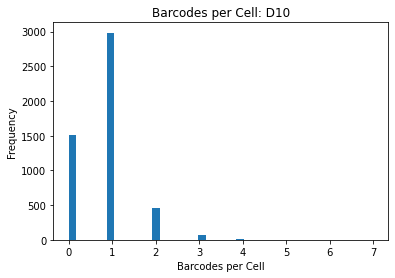

In [80]:
plt.hist(df_mid['Number_Barcodes'], bins =40)
plt.xticks()
plt.title("Barcodes per Cell: D10")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

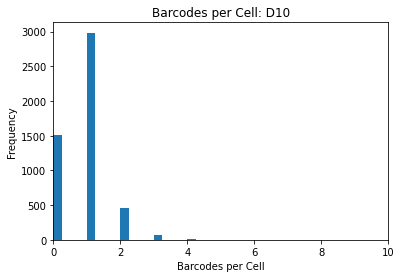

In [81]:
plt.hist(df_mid['Number_Barcodes'], bins =28)
plt.xticks()
plt.xlim([0,10])
plt.title("Barcodes per Cell: D10")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

In [82]:
np.mean(df_early['Number_Barcodes'])

0.99620548744892

In [83]:
np.mean(df_mid['Number_Barcodes'])

0.8261819626539532

# Cells per Clone: D17: Total

In [84]:
df_late= df_clones[df_clones['Timepoint']=='Day17']

In [85]:
df_late

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940,Timepoint,gfp_late,Number_Barcodes,Clonal Barcode
SITTC9AAACCCAAGATTGATG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,high,1.0,CCCGTGTTACCATACCACATCGGAATGTGTCGAAAGAGAT
SITTC9AAACCCAAGGGTGAAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,high,1.0,CACGTGTCCACATCCTACCTGCGACTTGGTAGAAAGACTA
SITTC9AAACCCACAAGCCTGC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,high,1.0,GCGATGCCACCAGGAGACTATGGATCATGTGGAAAGGGCG
SITTC9AAACCCACAAGGATGC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,high,1.0,AGCATGACATCAGAAAACAAATGACCATGTGATAAGACTT
SITTC9AAACCCAGTCATCGGC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,high,1.0,CCATTGGACGCAATGCACCCTTGATGACGTAACCAGTCAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGTTGTCAAGTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,0.0,
SITTB9TTTGTTGTCCACTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,0.0,
SITTB9TTTGTTGTCGAGGCAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,1.0,AACCTGTAACCAATTTACCGATCAAACAGTCAGCAGGGTA
SITTB9TTTGTTGTCTGCATAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,3.0,ATCCCGCTATCAAACGACCCGTGAAGTCGTCTGAAGCTCGCCATTG...


In [86]:
np.max(np.array(df_late.iloc[:,:-4].sum(axis = 0)))

617

In [88]:
np.log10(617)

2.7902851640332416

Text(0, 0.5, 'Frequency')

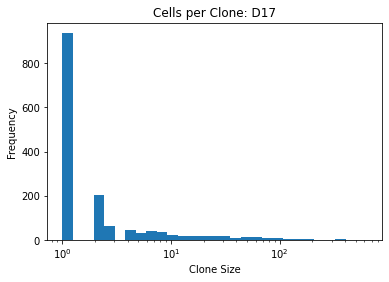

In [89]:
plt.hist(df_late.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 2.8, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D17")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

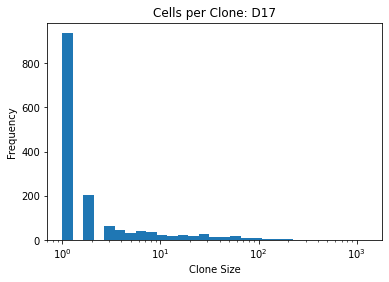

In [138]:
plt.hist(df_late.iloc[:,:-4].sum(axis = 0), bins=10**np.linspace(0, 3.1, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D17")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')

# Barcodes per Cell: D17

Text(0, 0.5, 'Frequency')

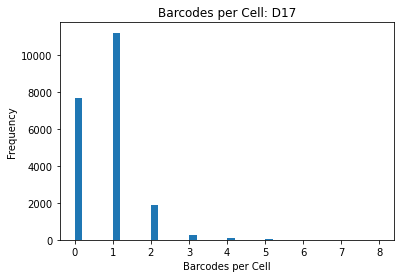

In [91]:
plt.hist(df_late['Number_Barcodes'], bins =40)
plt.xticks()
plt.title("Barcodes per Cell: D17")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

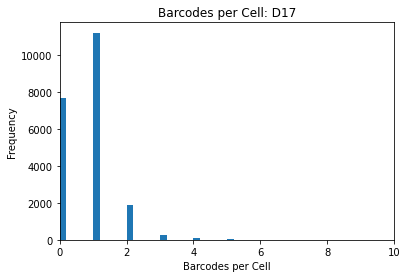

In [92]:
plt.hist(df_late['Number_Barcodes'], bins =40)
plt.xticks()
plt.xlim([0,10])
plt.title("Barcodes per Cell: D17")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

In [93]:
np.mean(df_early['Number_Barcodes'])

0.99620548744892

In [94]:
np.mean(df_mid['Number_Barcodes'])

0.8261819626539532

In [95]:
np.mean(df_late['Number_Barcodes'])

0.767134991456237

# Barcodes per Cell: GFPhi vs mid

In [96]:
mask = np.where(df_late['gfp_late'] == 'high')[0]

Text(0, 0.5, 'Frequency')

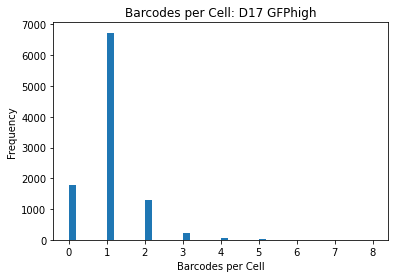

In [97]:
plt.hist(df_late['Number_Barcodes'][mask], bins =40)
plt.xticks()
plt.title("Barcodes per Cell: D17 GFPhigh")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

(0.0, 10.0)

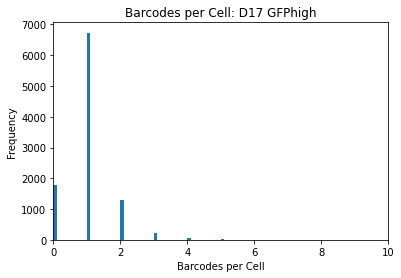

In [98]:
plt.hist(df_late['Number_Barcodes'][mask], bins =80)
plt.xticks()
plt.title("Barcodes per Cell: D17 GFPhigh")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')
plt.xlim([0,10])

In [99]:
mask2= np.where(df_late['gfp_late'] == 'mid')[0]

Text(0, 0.5, 'Frequency')

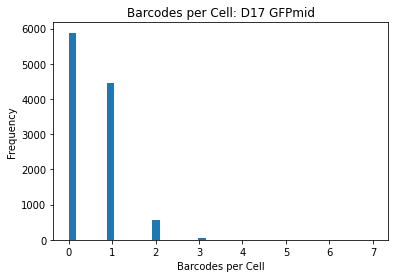

In [100]:
plt.hist(df_late['Number_Barcodes'][mask2], bins =40)
plt.xticks()
plt.title("Barcodes per Cell: D17 GFPmid")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')

(0.0, 10.0)

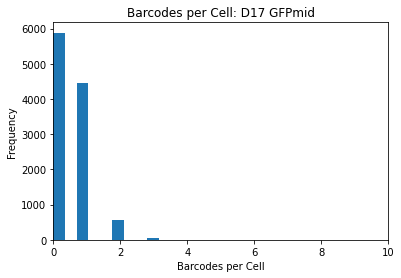

In [101]:
plt.hist(df_late['Number_Barcodes'][mask2], bins =20)
plt.xticks()
plt.title("Barcodes per Cell: D17 GFPmid")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')
plt.xlim([0,10])

In [102]:
np.mean(df_early['Number_Barcodes'])

0.99620548744892

In [103]:
np.mean(df_mid['Number_Barcodes'])

0.8261819626539532

In [104]:
np.mean(df_late['Number_Barcodes'])

0.767134991456237

In [105]:
np.mean(df_late['Number_Barcodes'][mask])

1.0244869634182612

In [106]:
np.mean(df_late['Number_Barcodes'][mask2])

0.530734905746289

In [107]:
# X Clones in Y Cells: D3 only
clone_count = 0 
cell_count = 0
for i in list_Day3: 
    clone_count += 1
    cell_count += np.sum(df_early[i] > 0)
print(clone_count)
print(cell_count)

1817
2218


In [108]:
# X Clones in Y Cells: D10 only
clone_count = 0 
cell_count = 0
for i in list_Day10: 
    clone_count += 1
    cell_count += np.sum(df_mid[i] > 0)
print(clone_count)
print(cell_count)

443
803


In [109]:
# X Clones in Y Cells: D17 only
clone_count = 0 
cell_count = 0
for i in list_Day17: 
    clone_count += 1
    cell_count += np.sum(df_late[i] > 0)
print(clone_count)
print(cell_count)

1039
2275


In [110]:
# X Clones in Y Cells: D3D10 
clone_count = 0 
cell_count = 0
for i in list_Day3Day10: 
    clone_count += 1
    cell_count += np.sum(df_clones[i] > 0)
print(clone_count)
print(cell_count)

133
489


In [111]:
# X Clones in Y Cells: D3D17 
clone_count = 0 
cell_count = 0
for i in list_Day3Day17: 
    clone_count += 1
    cell_count += np.sum(df_clones[i] > 0)
print(clone_count)
print(cell_count)

50
454


In [112]:
# X Clones in Y Cells: D10D17 
clone_count = 0 
cell_count = 0
for i in list_Day10Day17: 
    clone_count += 1
    cell_count += np.sum(df_clones[i] > 0)
print(clone_count)
print(cell_count)

333
9900


In [113]:
# X Clones in Y Cells: D3D10D17 
clone_count = 0 
cell_count = 0
for i in list_Day3Day10Day17: 
    clone_count += 1
    cell_count += np.sum(df_clones[i] > 0)
print(clone_count)
print(cell_count)

125
3458


In [114]:
list_Day3Day10Day17

['Clone_55',
 'Clone_59',
 'Clone_89',
 'Clone_103',
 'Clone_189',
 'Clone_256',
 'Clone_284',
 'Clone_287',
 'Clone_388',
 'Clone_429',
 'Clone_541',
 'Clone_632',
 'Clone_648',
 'Clone_651',
 'Clone_688',
 'Clone_691',
 'Clone_743',
 'Clone_754',
 'Clone_765',
 'Clone_772',
 'Clone_812',
 'Clone_832',
 'Clone_841',
 'Clone_998',
 'Clone_1012',
 'Clone_1155',
 'Clone_1212',
 'Clone_1213',
 'Clone_1214',
 'Clone_1230',
 'Clone_1253',
 'Clone_1299',
 'Clone_1346',
 'Clone_1362',
 'Clone_1466',
 'Clone_1481',
 'Clone_1496',
 'Clone_1540',
 'Clone_1563',
 'Clone_1630',
 'Clone_1717',
 'Clone_1758',
 'Clone_1816',
 'Clone_1867',
 'Clone_1944',
 'Clone_1959',
 'Clone_1964',
 'Clone_1966',
 'Clone_2149',
 'Clone_2209',
 'Clone_2228',
 'Clone_2232',
 'Clone_2291',
 'Clone_2298',
 'Clone_2383',
 'Clone_2387',
 'Clone_2425',
 'Clone_2457',
 'Clone_2463',
 'Clone_2468',
 'Clone_2491',
 'Clone_2499',
 'Clone_2505',
 'Clone_2539',
 'Clone_2550',
 'Clone_2557',
 'Clone_2560',
 'Clone_2561',
 'Clone

In [116]:
np.where(df_clones['Clone_55'] > 0)[0]

array([  782,  5897,  6394,  7143,  7160,  8981, 10973, 11139, 11417,
       11454, 11544, 11676, 12714, 13073, 14118, 15055, 16400, 17315,
       18418, 18572, 19138, 19422, 19510, 19897, 19898, 20034, 20265,
       20793, 20943, 21484, 21581, 22198, 22447, 22569, 22647, 22950,
       23384, 23434, 24046, 24191, 24264, 24397, 24486, 24756, 24798,
       24900, 25466, 25680, 25899, 26008, 26167, 26200, 26392, 26742,
       26856, 27121, 27136, 27302, 27829, 27939, 27953, 28043, 28451,
       28490, 29228])

In [118]:
df_clones.iloc[np.where(df_clones['Clone_55'] > 0)[0]]

,Clone_1,Clone_2,Clone_3,Clone_4,Clone_5,Clone_6,Clone_7,Clone_8,Clone_9,Clone_10,...,Clone_3935,Clone_3936,Clone_3937,Clone_3938,Clone_3939,Clone_3940,Timepoint,gfp_late,Number_Barcodes,Clonal Barcode
SITTG7ATTGGGTCAGCTCGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day3,,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB5GAAGGACGTAAGCTCT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB5GGAACCCAGGGTCAAC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB5TACCTGCGTGCTAGCC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB5TACGGTATCTTAGCTT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day10,,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TCTTCCTGTCGCTTAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB9TGACCCTTCAGCAGAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB9TGGATGTGTAGCTGTT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA
SITTB9TGGGATTTCTTCTGGC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Day17,mid,1.0,AAAATGCATGCACTGAACCGCCGAATAAGTGTCCAGAGCA


In [119]:
# Clonal Size of D3D10D17 Clones

In [120]:
df_clones[list_Day3Day10Day17]

,Clone_55,Clone_59,Clone_89,Clone_103,Clone_189,Clone_256,Clone_284,Clone_287,Clone_388,Clone_429,...,Clone_3780,Clone_3783,Clone_3802,Clone_3807,Clone_3813,Clone_3847,Clone_3869,Clone_3876,Clone_3883,Clone_3908
SITTG7AAACCCACAAATCAAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACCCAGTTGCTCGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAAAGAGGTATT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAACAAGCAGGT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTG7AAACGAATCAGGACGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SITTB9TTTGTTGTCAAGTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCCACTGGG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCGAGGCAA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SITTB9TTTGTTGTCTGCATAG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
np.max(df_clones[list_Day3Day10Day17].sum(axis = 0))

211

In [122]:
np.log10(211)

2.3242824552976926

Text(0, 0.5, 'Frequency')

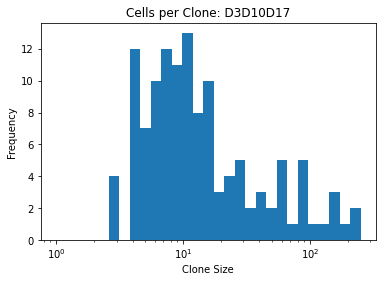

In [123]:
plt.hist(df_clones[list_Day3Day10Day17].sum(axis = 0), bins=10**np.linspace(0, 2.4, 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D3D10D17")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')


Text(0, 0.5, 'Frequency')

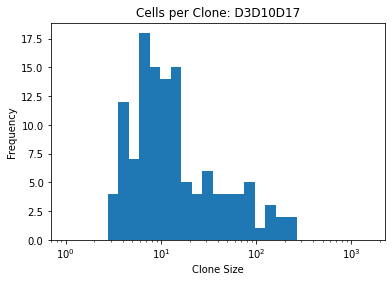

In [126]:
#for comparison with FL
plt.hist(df_clones[list_Day3Day10Day17].sum(axis = 0), bins=10**np.linspace(0, 3.2
                                                                        , 30))
plt.xticks()
plt.xscale("log")
plt.title("Cells per Clone: D3D10D17")
plt.xlabel('Clone Size')
plt.ylabel('Frequency')


(0.0, 10.0)

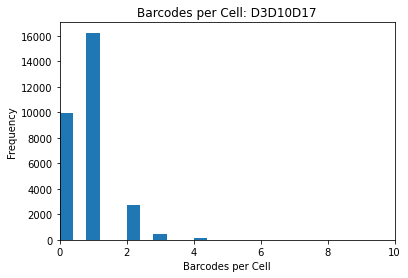

In [128]:
# Barcodes per cell D3D10D17
plt.hist(df_clones['Number_Barcodes'][df_clones[list_Day3Day10Day17].index], bins =20)
plt.xticks()
plt.title("Barcodes per Cell: D3D10D17")
plt.xlabel('Barcodes per Cell')
plt.ylabel('Frequency')
plt.xlim([0,10])

In [130]:
df_clones[list_Day3Day10Day17].index

Index(['SITTG7AAACCCACAAATCAAG', 'SITTG7AAACCCAGTTGCTCGG',
       'SITTG7AAACGAAAGAGGTATT', 'SITTG7AAACGAACAAGCAGGT',
       'SITTG7AAACGAATCAGGACGA', 'SITTG7AAACGAATCCAGCTCT',
       'SITTG7AAACGAATCCTAGCTC', 'SITTG7AAACGAATCCTCATAT',
       'SITTG7AAACGAATCTGTCCCA', 'SITTG7AAACGAATCTTTGCGC',
       ...
       'SITTB9TTTGTTGGTCCTTAAG', 'SITTB9TTTGTTGGTCGGCTAC',
       'SITTB9TTTGTTGGTGGCAGAT', 'SITTB9TTTGTTGGTGTTGACT',
       'SITTB9TTTGTTGGTTAAGACA', 'SITTB9TTTGTTGTCAAGTGGG',
       'SITTB9TTTGTTGTCCACTGGG', 'SITTB9TTTGTTGTCGAGGCAA',
       'SITTB9TTTGTTGTCTGCATAG', 'SITTB9TTTGTTGTCTTCTGTA'],
      dtype='object', length=29528)

In [131]:
df_clones['Number_Barcodes']

SITTG7AAACCCACAAATCAAG    1.0
SITTG7AAACCCAGTTGCTCGG    1.0
SITTG7AAACGAAAGAGGTATT    2.0
SITTG7AAACGAACAAGCAGGT    1.0
SITTG7AAACGAATCAGGACGA    1.0
                         ... 
SITTB9TTTGTTGTCAAGTGGG    0.0
SITTB9TTTGTTGTCCACTGGG    0.0
SITTB9TTTGTTGTCGAGGCAA    1.0
SITTB9TTTGTTGTCTGCATAG    3.0
SITTB9TTTGTTGTCTTCTGTA    1.0
Name: Number_Barcodes, Length: 29528, dtype: float64